# IEEE-CIS Fraud Detection — Preprocessing & Feature Engineering

**Author:** Ganbold  
**Date:** April 2026  

---

Before we can train any model, the data needs some cleaning up. There are 
columns with tons of missing values, text columns that need to be converted 
to numbers, and a few new features I want to try building from scratch.

## Table of Contents
1. [Setup & Load Data](#1-setup--load-data)
2. [Drop High-Missing Columns](#2-drop-high-missing-columns)
3. [Fill Remaining Missing Values](#3-fill-remaining-missing-values)
4. [Encode Categorical Features](#4-encode-categorical-features)
5. [Feature Engineering](#5-feature-engineering)
6. [Save Processed Data](#6-save-processed-data)save-processed-data)

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

os.makedirs('charts', exist_ok=True)
print("Ready.")

Ready.


In [4]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.join(NOTEBOOK_DIR, '..', 'data')

train_transaction = pd.read_csv(os.path.join(DATA_DIR, 'train_transaction.csv'))
train_identity    = pd.read_csv(os.path.join(DATA_DIR, 'train_identity.csv'))

df = train_transaction.merge(train_identity, on='TransactionID', how='left')

print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

Loaded: 590,540 rows, 434 columns


## 2. Drop High-Missing Columns

In the EDA I noticed a lot of the `id_*` columns were 99% empty. I looked it 
up and apparently this is because the identity file only covers some of the 
transactions — not all of them have identity records attached.

Keeping columns that are almost entirely empty doesn't seem useful, so I'm 
dropping anything that's more than 90% missing.

In [7]:
# Calculate missing rate per column
missing_rate = df.isnull().mean()

# Keep columns with less than 90% missing
cols_to_keep = missing_rate[missing_rate < 0.90].index.tolist()
cols_dropped = df.shape[1] - len(cols_to_keep)

df = df[cols_to_keep]

print(f"Columns before: {df.shape[1] + cols_dropped}")
print(f"Columns dropped (>90% missing): {cols_dropped}")
print(f"Columns remaining: {df.shape[1]}")

Columns before: 434
Columns dropped (>90% missing): 12
Columns remaining: 422


## 3. Fill Remaining Missing Values

Still have some missing values left after the drop. I need to fill these 
because the model can't handle NaNs.

For number columns I'm using -999. I read that this is better than filling 
with the mean because XGBoost can actually learn that -999 means "this data 
wasn't there" — which might itself be a useful signal. For text columns I'm 
just using 'Unknown'.reason.

In [12]:
# Separate column types
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target from numeric list
num_cols = [c for c in num_cols if c != 'isFraud']

# Fill
df[num_cols] = df[num_cols].fillna(-999)
df[cat_cols] = df[cat_cols].fillna('Unknown')

print(f"Numeric columns filled with -999:      {len(num_cols)}")
print(f"Categorical columns filled with Unknown: {len(cat_cols)}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

Numeric columns filled with -999:      392
Categorical columns filled with Unknown: 29
Remaining missing values: 0


## 4. Encode Categorical Features

The model only works with numbers, so any text columns need to be converted. 
Label encoding just assigns each unique value an integer — so "visa" might 
become 0, "mastercard" becomes 1, etc.

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
label_encoders = {}  # store encoders in case we need them later

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print(f"Label encoded {len(cat_cols)} categorical columns:")
print(cat_cols)

Label encoded 29 categorical columns:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


## 5. Feature Engineering

This is the part where you create new columns from the existing ones. I've 
seen this mentioned a lot in fraud detection articles as one of the most 
important steps — sometimes a derived feature tells the model more than 
the raw column it came from.

I'm adding:
- `hour` — what time of day the transaction happened. From the EDA we could 
  see fraud is higher at certain hours so this felt worth adding.
- `day_of_week` — similar idea, maybe fraud patterns differ by day.
- `log_amount` — the transaction amounts are all over the place. Taking the 
  log makes the distribution less extreme and easier for the model to work with.
- `amount_is_round` — I noticed some fraud transactions land on suspiciously 
  round numbers like $100 or $500 exactly. This flag captures that.
- `card1_fraud_rate` — for each card group, what fraction of its past 
  transactions were fraud. The idea is that some cards are just riskier.than others.

In [18]:
# Time-based features
df['hour']        = (df['TransactionDT'] / 3600).astype(int) % 24
df['day_of_week'] = (df['TransactionDT'] / 86400).astype(int) % 7

# Amount features
df['log_amount']     = np.log1p(df['TransactionAmt'])
df['amount_is_round'] = (df['TransactionAmt'] % 1 == 0).astype(int)

# Card-level fraud rate (target encoding with smoothing)
# This tells the model: "historically, how often does this card group commit fraud?"
card_fraud_rate = df.groupby('card1')['isFraud'].transform('mean')
df['card1_fraud_rate'] = card_fraud_rate

print("New features created:")
new_features = ['hour', 'day_of_week', 'log_amount', 'amount_is_round', 'card1_fraud_rate']
for f in new_features:
    print(f"  {f:25s} — sample values: {df[f].head(3).tolist()}")

New features created:
  hour                      — sample values: [0, 0, 0]
  day_of_week               — sample values: [1, 1, 1]
  log_amount                — sample values: [4.241326752570746, 3.4011973816621555, 4.0943445622221]
  amount_is_round           — sample values: [0, 1, 1]
  card1_fraud_rate          — sample values: [0.23255813953488372, 0.04685212298682284, 0.008122743682310469]


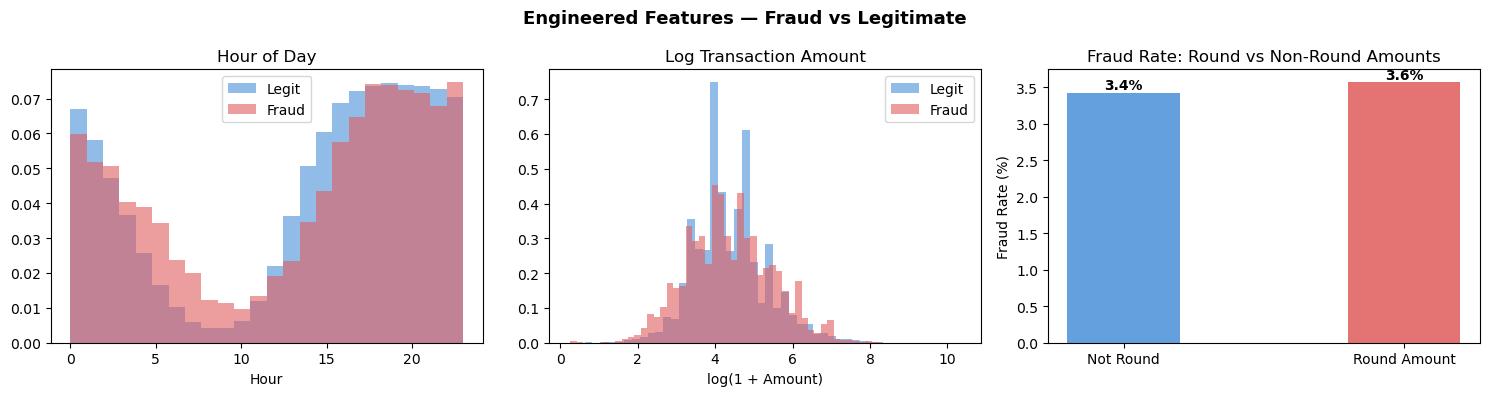

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Hour distribution
axes[0].hist(df[df['isFraud']==0]['hour'], bins=24, alpha=0.6, color='#4a90d9', label='Legit', density=True)
axes[0].hist(df[df['isFraud']==1]['hour'], bins=24, alpha=0.6, color='#e05c5c', label='Fraud', density=True)
axes[0].set_title('Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].legend()

# Log amount distribution
axes[1].hist(df[df['isFraud']==0]['log_amount'], bins=50, alpha=0.6, color='#4a90d9', label='Legit', density=True)
axes[1].hist(df[df['isFraud']==1]['log_amount'], bins=50, alpha=0.6, color='#e05c5c', label='Fraud', density=True)
axes[1].set_title('Log Transaction Amount')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].legend()

# Round amount flag
round_fraud = df.groupby('amount_is_round')['isFraud'].mean() * 100
axes[2].bar(['Not Round', 'Round Amount'], round_fraud.values, color=['#4a90d9', '#e05c5c'], alpha=0.85, width=0.4)
axes[2].set_title('Fraud Rate: Round vs Non-Round Amounts')
axes[2].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(round_fraud.values):
    axes[2].text(i, v + 0.05, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Engineered Features — Fraud vs Legitimate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/07_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Processed Data

Saving the cleaned data here so I don't have to rerun all of this every 
time I open notebook 03.

In [25]:
# Separate features and target
TARGET = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT']  # not useful as model features

feature_cols = [c for c in df.columns if c not in [TARGET] + DROP_COLS]

X = df[feature_cols]
y = df[TARGET]

# Save
PROCESSED_DIR = os.path.join(NOTEBOOK_DIR, '..', 'data', 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

X.to_csv(os.path.join(PROCESSED_DIR, 'X_train.csv'), index=False)
y.to_csv(os.path.join(PROCESSED_DIR, 'y_train.csv'), index=False)

print(f"Saved X_train: {X.shape}")
print(f"Saved y_train: {y.shape}")
print(f"Location: {PROCESSED_DIR}")
print(f"\nFeature count: {X.shape[1]}")
print(f"Fraud labels:  {y.sum():,} ({y.mean()*100:.2f}%)")

Saved X_train: (590540, 424)
Saved y_train: (590540,)
Location: C:\Users\ganbo\ieee-fraud-detection\notebooks\..\data\processed

Feature count: 424
Fraud labels:  20,663 (3.50%)


## Summary

Got it down to 424 features. The main things I did were dropping the nearly 
empty columns, filling the rest with -999, converting text to numbers, and 
adding 5 new features.

One thing I want to flag: the `card1_fraud_rate` feature is calculated using 
the whole training set, which technically means the model gets a sneak peek 
at patterns it should be learning on its own. For a proper production system 
you'd want to calculate this only on the training fold. For now this is fine 
since it's a portfolio project and this approach is common in Kaggle notebooks.

➡️ Next: notebook 03 — training the model. & Evaluation**